In [10]:
# ==============================================================================
# BLOCK 1: ENVIRONMENT SETUP & JOURNAL-STYLE VISUALIZATION
# ==============================================================================
# This block initializes directories, imports scientific packages, and enforces 
# strict journal publication standards (Times New Roman, black axes, high-DPI).

import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import joblib
import shap
from scipy import stats

from sklearn.svm import SVR
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib as mpl

# Define Directory and Global Configurations
file_path = r"C:\Users\truongphatdat\OneDrive\2026_V-bending_Project-01\V-bending\V-bending_Dataset.xlsx"
output_dir = r"C:\Users\truongphatdat\OneDrive\2026_V-bending_Project-01\V-bending\V-bending_SVR_results"
os.makedirs(output_dir, exist_ok=True)

model_features = ["A [%t]", "B [°]", "C [mm]", "D [°]"]
target_name = "Mean angle [°]"

def set_journal_plot_style():
    font_paths = [
        r"C:\Windows\Fonts\times.ttf", r"C:\Windows\Fonts\timesbd.ttf",
        r"C:\Windows\Fonts\timesi.ttf", r"C:\Windows\Fonts\timesbi.ttf"
    ]
    for path in font_paths:
        if os.path.exists(path):
            font_manager.fontManager.addfont(path)
            
    mpl.rcParams["font.family"] = "Times New Roman"
    mpl.rcParams["mathtext.fontset"] = "stix"
    mpl.rcParams["font.size"] = 14
    mpl.rcParams["axes.labelsize"] = 14
    mpl.rcParams["xtick.labelsize"] = 13
    mpl.rcParams["ytick.labelsize"] = 13
    mpl.rcParams["legend.fontsize"] = 12
    mpl.rcParams["savefig.dpi"] = 600
    
    # Force explicit black lines/text for publication standards
    mpl.rcParams["text.color"] = "black"
    mpl.rcParams["axes.labelcolor"] = "black"
    mpl.rcParams["xtick.color"] = "black"
    mpl.rcParams["ytick.color"] = "black"
    mpl.rcParams["axes.edgecolor"] = "black"

set_journal_plot_style()

def save_publication_figure(filename):
    plt.savefig(os.path.join(output_dir, f"{filename}.pdf"), bbox_inches="tight", pad_inches=0.03)
    plt.savefig(os.path.join(output_dir, f"{filename}.png"), dpi=600, bbox_inches="tight", pad_inches=0.03)

# Fix alias for background compatibility
save_figure = save_publication_figure

print("Environment setup and plot styling completed successfully. Alias 'save_figure' is now locked.")

Environment setup and plot styling completed successfully. Alias 'save_figure' is now locked.


In [11]:
# ==============================================================================
# BLOCK 2: DATA LOADING AND PREPROCESSING
# ==============================================================================
# This block handles robust column-name matching, target extraction, 
# and serializes raw arrays to disk for reproducibility.

df = pd.read_excel(file_path)
df.columns = df.columns.astype(str).str.strip()

def normalize_column_name(name):
    name = str(name).strip().replace("º", "°").replace("[o]", "[°]").replace("[O]", "[°]")
    name = name.replace("−", "-").replace("–", "-")
    return " ".join(name.split()).lower()

def match_target_column(df, candidates):
    normalized_mapping = {normalize_column_name(c): c for c in df.columns}
    for cand in candidates:
        cand_norm = normalize_column_name(cand)
        if cand_norm in normalized_mapping:
            return normalized_mapping[cand_norm]
    raise KeyError(f"Target column matching failed for candidates: {candidates}")

source_feature_cols = [
    match_target_column(df, ["A [%t]", "A [%T]", "Grooving depth"]),
    match_target_column(df, ["B [°]", "B [º]", "Grooving angle"]),
    match_target_column(df, ["C [mm]", "Nose radius"]),
    match_target_column(df, ["D [°]", "D [º]", "Rolling direction"])
]
source_target_col = match_target_column(df, ["Mean angle [°]", "Average", "Mean Angle"])

X = df[source_feature_cols].copy()
X.columns = model_features
y = df[source_target_col].copy()
y.name = target_name

joblib.dump(X, os.path.join(output_dir, "X.joblib"))
joblib.dump(y, os.path.join(output_dir, "y.joblib"))

print(f"Dataset securely loaded. Shape: {df.shape}")

Dataset securely loaded. Shape: (81, 11)


In [12]:
# ==============================================================================
# BLOCK 3: SVR INFRASTRUCTURE & PARAMETER CONFIGURATIONS
# ==============================================================================
# This block builds the pipeline with StandardScaler and defines 
# the discrete search grids for Baseline vs. Tuned evaluations.

def build_transformed_regressor():
    pipe = Pipeline([("scaler_X", StandardScaler()), ("svr", SVR())])
    return TransformedTargetRegressor(regressor=pipe, transformer=StandardScaler())

def clean_param_name(param_name):
    return param_name.replace("regressor__svr__", "")

def results_to_dataframe(results):
    rows = []
    for kernel_name, result in results.items():
        row = {
            "Case": result["Case"], "Kernel": result["Kernel"],
            "R2_LOOCV": result["R2_LOOCV"], "RMSE_LOOCV": result["RMSE_LOOCV"], "MAE_LOOCV": result["MAE_LOOCV"]
        }
        for key, value in result["Best parameters"].items():
            row[clean_param_name(key)] = value
        rows.append(row)
    return pd.DataFrame(rows)

baseline_param_grids = {
    "Linear": {"regressor__svr__kernel": ["linear"], "regressor__svr__C": [5], "regressor__svr__epsilon": [0.01]},
    "Polynomial": {"regressor__svr__kernel": ["poly"], "regressor__svr__degree": [2], "regressor__svr__C": [5], "regressor__svr__epsilon": [0.01], "regressor__svr__gamma": ["scale"], "regressor__svr__coef0": [1]},
    "RBF": {"regressor__svr__kernel": ["rbf"], "regressor__svr__C": [5], "regressor__svr__epsilon": [0.01], "regressor__svr__gamma": ["scale"]}
}

tuned_param_grids = {
    "Linear": {"regressor__svr__kernel": ["linear"], "regressor__svr__C": [0.1, 1, 5, 10, 50, 100], "regressor__svr__epsilon": [0.001, 0.01, 0.05, 0.1]},
    "Polynomial": {"regressor__svr__kernel": ["poly"], "regressor__svr__degree": [2, 3], "regressor__svr__C": [0.1, 1, 5, 10, 50, 100], "regressor__svr__epsilon": [0.001, 0.01, 0.05, 0.1], "regressor__svr__gamma": ["scale", 0.01, 0.05, 0.1, 1], "regressor__svr__coef0": [0, 1]},
    "RBF": {"regressor__svr__kernel": ["rbf"], "regressor__svr__C": [0.1, 1, 5, 10, 50, 100], "regressor__svr__epsilon": [0.001, 0.01, 0.05, 0.1], "regressor__svr__gamma": ["scale", 0.01, 0.05, 0.1, 1]}
}

In [13]:
# ==============================================================================
# BLOCK 4: RUNNING MODEL EVALUATIONS
# ==============================================================================
# This block executes Leave-One-Out Cross-Validation (LOO-CV) for SVR hyperparameter
# tuning and saves the optimized RBF model as the final predictive surrogate.

def run_svr_set(X, y, param_grids, case_name):
    loo = LeaveOneOut()
    results, models, predictions = {}, {}, {}
    
    for kernel_name, param_grid in param_grids.items():
        grid = GridSearchCV(estimator=build_transformed_regressor(), param_grid=param_grid,
                            scoring="neg_root_mean_squared_error", cv=loo, n_jobs=-1, refit=True)
        grid.fit(X, y)
        best_model = grid.best_estimator_
        y_pred_cv = cross_val_predict(best_model, X, y, cv=loo, n_jobs=-1)
        
        results[kernel_name] = {
            "Case": case_name, "Kernel": kernel_name, "Best parameters": grid.best_params_,
            "R2_LOOCV": r2_score(y, y_pred_cv), "RMSE_LOOCV": np.sqrt(mean_squared_error(y, y_pred_cv)), "MAE_LOOCV": mean_absolute_error(y, y_pred_cv)
        }
        models[kernel_name] = best_model
        predictions[kernel_name] = {"y_true": y.values, "y_pred": y_pred_cv}
        
    return results, models, predictions

baseline_results, baseline_models, baseline_predictions = run_svr_set(X, y, baseline_param_grids, "Baseline")
tuned_results, tuned_models, tuned_predictions = run_svr_set(X, y, tuned_param_grids, "Grid Search")

# Save summaries
baseline_df = results_to_dataframe(baseline_results)
tuned_df = results_to_dataframe(tuned_results)
comparison_df = pd.concat([baseline_df, tuned_df], ignore_index=True)
comparison_df.to_excel(os.path.join(output_dir, "baseline_vs_grid_search_summary.xlsx"), index=False)

# Lock and fit the final SVR-RBF model
final_model = tuned_models["RBF"]
final_model.fit(X, y)
joblib.dump(final_model, os.path.join(output_dir, "final_tuned_svr_rbf.joblib"))
print("Baseline and Tuned evaluations completed and comparison matrix saved.")

Baseline and Tuned evaluations completed and comparison matrix saved.



FAIR LOO-CV COMPARISON: REDUCED RSM VS. SVR-RBF
Metric                           Reduced RSM           SVR-RBF
------------------------------------------------------------------------
R2_LOOCV                              0.9616            0.9744
RMSE_LOOCV [°]                        0.9563            0.7801
MAE_LOOCV [°]                         0.7050            0.5052
------------------------------------------------------------------------


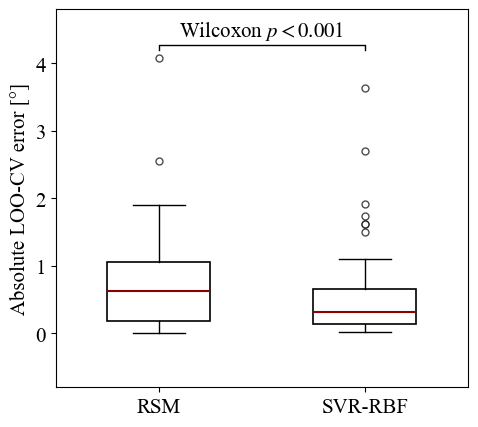

In [14]:
# ==============================================================================
# BLOCK 5: FAIR LOO-CV COMPARISON BETWEEN REDUCED RSM AND SVR-RBF
# ==============================================================================
# Evaluates RSM vs SVR-RBF on identical validation folds and applies a one-sided
# Wilcoxon signed-rank test on paired absolute errors.

from sklearn.base import clone
from sklearn.linear_model import LinearRegression

def make_reduced_rsm_features(X_input):
    Z = pd.DataFrame(index=X_input.index)
    Z["A"] = X_input["A [%t]"]
    Z["B"] = X_input["B [°]"]
    Z["C"] = X_input["C [mm]"]
    Z["A2"] = X_input["A [%t]"] ** 2
    Z["B2"] = X_input["B [°]"] ** 2
    Z["C2"] = X_input["C [mm]"] ** 2
    return Z

fixed_svr_rbf = build_transformed_regressor()
fixed_svr_rbf.set_params(
    regressor__svr__kernel="rbf",
    regressor__svr__C=10,
    regressor__svr__epsilon=0.01,
    regressor__svr__gamma=0.1
)

loo = LeaveOneOut()
y_true_vals = y.to_numpy()
y_pred_rsm_loo = np.zeros(len(y), dtype=float)
y_pred_svr_loo = np.zeros(len(y), dtype=float)

for train_idx, test_idx in loo.split(X):
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx]

    rsm_model = LinearRegression()
    rsm_model.fit(make_reduced_rsm_features(X_train), y_train)
    y_pred_rsm_loo[test_idx] = rsm_model.predict(make_reduced_rsm_features(X_test))

    svr_model = clone(fixed_svr_rbf)
    svr_model.fit(X_train, y_train)
    y_pred_svr_loo[test_idx] = svr_model.predict(X_test)

def calculate_prediction_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

rsm_metrics = calculate_prediction_metrics(y_true_vals, y_pred_rsm_loo)
svr_metrics = calculate_prediction_metrics(y_true_vals, y_pred_svr_loo)

ae_rsm = np.abs(y_true_vals - y_pred_rsm_loo)
ae_svr = np.abs(y_true_vals - y_pred_svr_loo)

wilcoxon_stat, p_value = stats.wilcoxon(ae_rsm, ae_svr, alternative="greater", zero_method="wilcox")

print("\n" + "=" * 72)
print("FAIR LOO-CV COMPARISON: REDUCED RSM VS. SVR-RBF")
print("=" * 72)
print(f"{'Metric':<26}{'Reduced RSM':>18}{'SVR-RBF':>18}")
print("-" * 72)
print(f"{'R2_LOOCV':<26}{rsm_metrics['R2']:>18.4f}{svr_metrics['R2']:>18.4f}")
print(f"{'RMSE_LOOCV [°]':<26}{rsm_metrics['RMSE']:>18.4f}{svr_metrics['RMSE']:>18.4f}")
print(f"{'MAE_LOOCV [°]':<26}{rsm_metrics['MAE']:>18.4f}{svr_metrics['MAE']:>18.4f}")
print("-" * 72)

error_summary = pd.DataFrame({
    "Metric": ["Mean absolute error", "Median absolute error", "75th percentile", "95th percentile", "Maximum absolute error"],
    "Reduced RSM [°]": [np.mean(ae_rsm), np.median(ae_rsm), np.percentile(ae_rsm, 75), np.percentile(ae_rsm, 95), np.max(ae_rsm)],
    "SVR-RBF [°]": [np.mean(ae_svr), np.median(ae_svr), np.percentile(ae_svr, 75), np.percentile(ae_svr, 95), np.max(ae_svr)]
})

paired_prediction_results = pd.DataFrame({
    "Experimental [°]": y_true_vals,
    "RSM LOO Prediction [°]": y_pred_rsm_loo,
    "SVR-RBF LOO Prediction [°]": y_pred_svr_loo,
    "RSM Absolute Error [°]": ae_rsm,
    "SVR-RBF Absolute Error [°]": ae_svr,
    "Error Difference RSM-SVR [°]": ae_rsm - ae_svr
})

paired_prediction_results.to_excel(os.path.join(output_dir, "paired_loo_predictions_rsm_vs_svr.xlsx"), index=False)
error_summary.to_excel(os.path.join(output_dir, "paired_loo_error_summary.xlsx"), index=False)

y_pred_rsm = y_pred_rsm_loo
y_pred_rbf = y_pred_svr_loo
ae_rbf = ae_svr

# Generate Boxplot for absolute error distributions
plt.figure(figsize=(5, 4.5))
box = plt.boxplot([ae_rsm, ae_svr], patch_artist=True, labels=["RSM", "SVR-RBF"], widths=0.5)

for patch in box["boxes"]:
    patch.set_facecolor("white")
    patch.set_edgecolor("black")
    patch.set_linewidth(1.2)

for median in box["medians"]:
    median.set_color("darkred")
    median.set_linewidth(1.5)

for flier in box["fliers"]:
    flier.set(marker="o", markerfacecolor="white", markeredgecolor="black", alpha=0.7, markersize=5)

plt.ylabel("Absolute LOO-CV error [°]", fontsize=15)
ax = plt.gca()
ax.tick_params(axis="both", colors="black", labelsize=15)

y_max = max(np.max(ae_rsm), np.max(ae_svr))
x1, x2 = 1, 2
y_bracket = y_max + 0.12
h_bracket = 0.08

plt.plot([x1, x1, x2, x2], [y_bracket, y_bracket + h_bracket, y_bracket + h_bracket, y_bracket], linewidth=1.0, color="black")
p_text = r"Wilcoxon $p<0.001$" if p_value < 0.001 else rf"Wilcoxon $p={p_value:.3f}$"
plt.text(1.5, y_bracket + h_bracket + 0.04, p_text, ha="center", va="bottom", fontsize=15)
plt.ylim(-0.8, 4.8)

for spine in ax.spines.values():
    spine.set_color("black")

plt.tight_layout()
save_publication_figure("absolute_error_boxplot_wilcoxon")
plt.show()

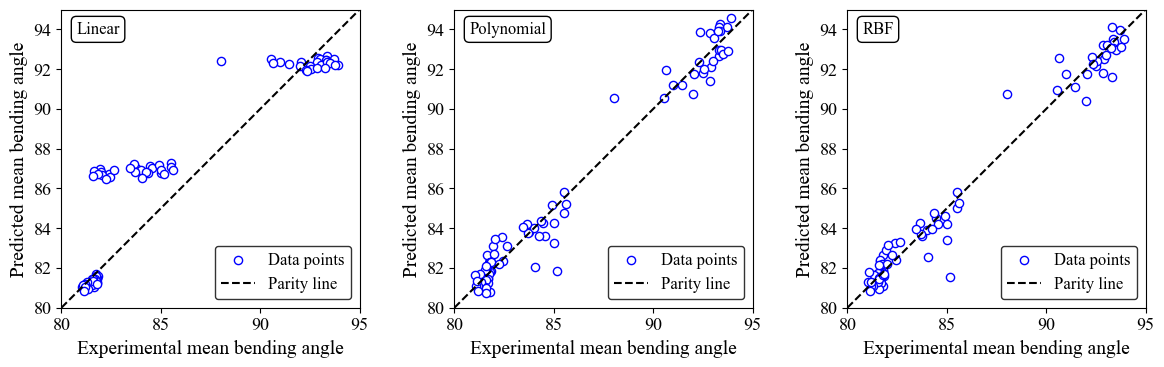

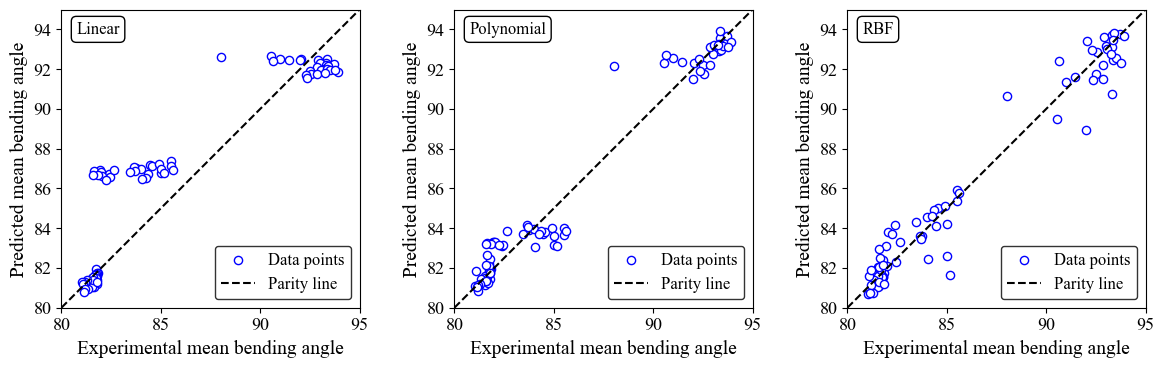

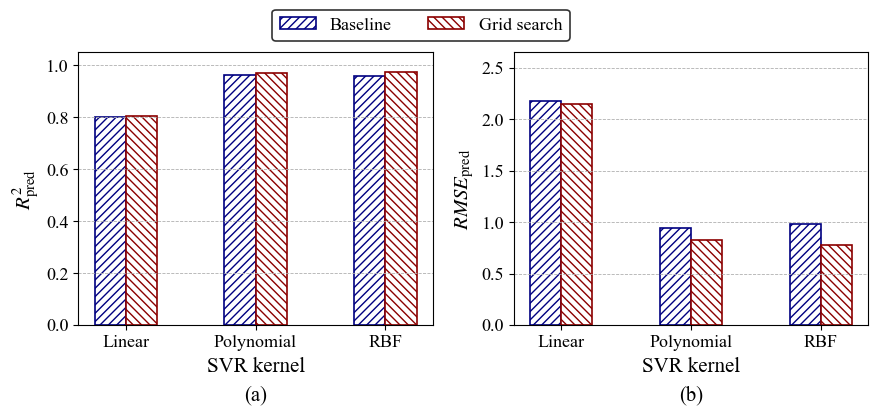

In [15]:
# ==============================================================================
# BLOCK 6: GRAPHICS GENERATION (PARITY & PERFORMANCE COMPARISON)
# ==============================================================================
# This block generates parity scatter plots for SVR kernels and a side-by-side 
# bar subplot comparing Baseline vs. Grid Search.

def plot_parity_journal(predictions, filename):
    plt.figure(figsize=(12, 4))
    for idx, name in enumerate(["Linear", "Polynomial", "RBF"], 1):
        plt.subplot(1, 3, idx)
        plt.scatter(predictions[name]["y_true"], predictions[name]["y_pred"], s=35, facecolors="white", edgecolors="blue", linewidths=1.0, label="Data points")
        plt.plot([80, 95], [80, 95], linestyle="--", linewidth=1.5, color="black", label="Parity line")
        plt.xlim(80, 95); plt.ylim(80, 95)
        plt.xlabel("Experimental mean bending angle")
        plt.ylabel("Predicted mean bending angle")
        plt.gca().set_aspect("equal", adjustable="box")
        leg = plt.legend(loc="lower right", frameon=True, edgecolor="black")
        leg.get_frame().set_linewidth(1.0)
        plt.text(0.05, 0.92, name, transform=plt.gca().transAxes, fontsize=12, bbox=dict(boxstyle="round", facecolor="white", edgecolor="black"))
    plt.tight_layout()
    save_figure(filename)
    plt.show()

plot_parity_journal(tuned_predictions, "fit-plot_tuned_kernels")
plot_parity_journal(baseline_predictions, "fit-plot_baseline_kernels")

# Generate performance comparison subplots (R2 & RMSE)
kernels = ["Linear", "Polynomial", "RBF"]
x = np.arange(len(kernels))
width = 0.24
hatch_baseline, hatch_grid = "////", "\\\\\\\\"

baseline_r2 = [baseline_results[k]["R2_LOOCV"] for k in kernels]
tuned_r2 = [tuned_results[k]["R2_LOOCV"] for k in kernels]
baseline_rmse = [baseline_results[k]["RMSE_LOOCV"] for k in kernels]
tuned_rmse = [tuned_results[k]["RMSE_LOOCV"] for k in kernels]

fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.4))
for idx, (b_data, t_data, label, y_lim, sub) in enumerate([(baseline_r2, tuned_r2, r"$R^{2}_{\mathrm{pred}}$", 1.05, "(a)"), (baseline_rmse, tuned_rmse, r"$\mathit{RMSE}_{\mathrm{pred}}$", 2.65, "(b)")]):
    ax = axes[idx]
    b_bar = ax.bar(x - width/2, b_data, width, facecolor="white", edgecolor="navy", linewidth=1.2, hatch=hatch_baseline, label="Baseline")
    t_bar = ax.bar(x + width/2, t_data, width, facecolor="white", edgecolor="darkred", linewidth=1.2, hatch=hatch_grid, label="Grid search")
    ax.set_xticks(x); ax.set_xticklabels(kernels); ax.set_ylabel(label, fontsize=15); ax.set_xlabel("SVR kernel", fontsize=15); ax.set_ylim(0, y_lim)
    ax.grid(axis="y", linestyle="--", linewidth=0.6)
    ax.text(0.5, -0.22, sub, transform=ax.transAxes, fontsize=15, ha="center", va="top")

leg = fig.legend([b_bar[0], t_bar[0]], ["Baseline", "Grid search"], loc="upper center", ncol=2, frameon=True, edgecolor="black", bbox_to_anchor=(0.48, 1.0), fontsize=13)
leg.get_frame().set_linewidth(1.2)
plt.tight_layout(rect=[0, 0, 1, 0.93])
save_figure("baseline_vs_grid_search_subplot.pdf")
plt.show()

Starting Advanced Explainer Kernel Computations (SHAP)...


  0%|          | 0/81 [00:00<?, ?it/s]

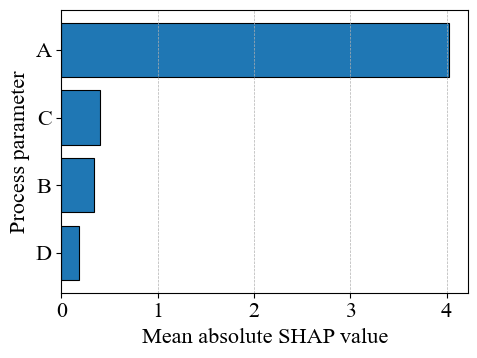

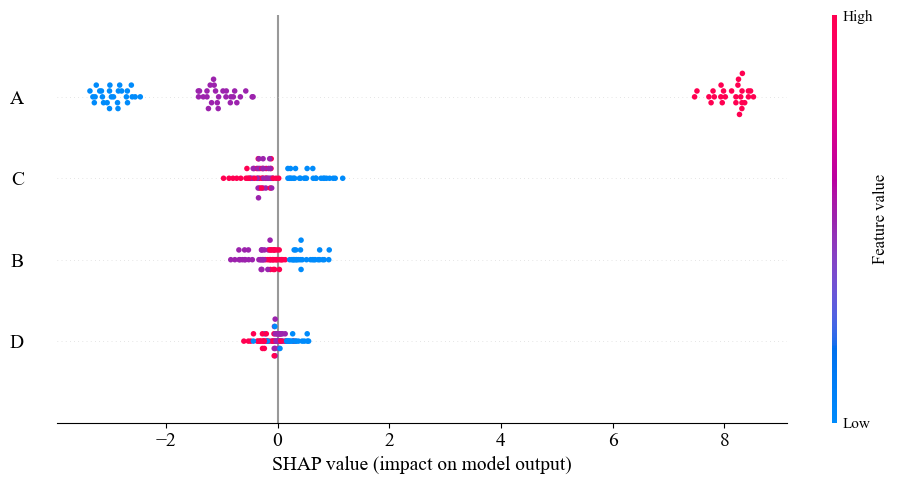

<Figure size 400x400 with 0 Axes>

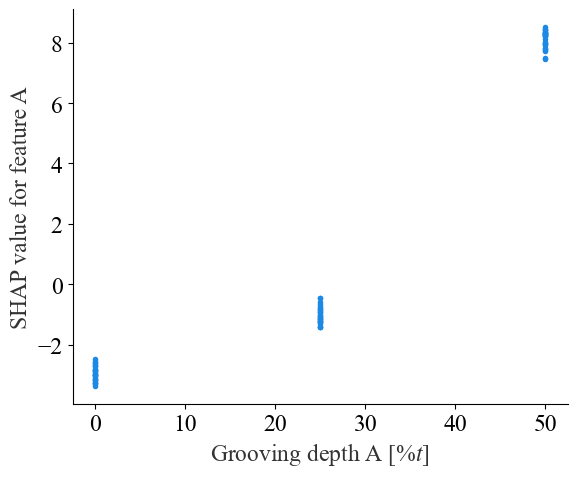

  0%|          | 0/81 [00:00<?, ?it/s]

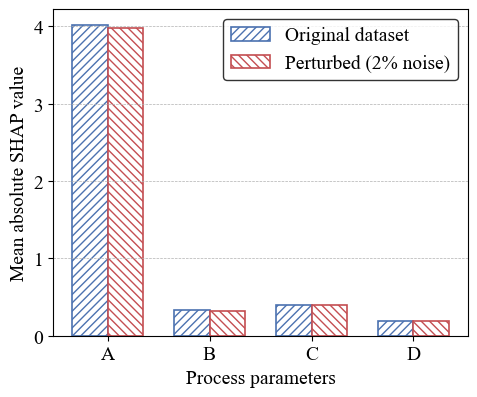

Feature [A] -> Shift: 1.16%
Feature [B] -> Shift: 4.39%
Feature [C] -> Shift: 0.17%
Feature [D] -> Shift: 2.44%


In [16]:
# ==============================================================================
# BLOCK 7: EXPLAINABLE AI SHAP AND PERTURBATION ANALYSIS
# ==============================================================================
# Implements global/local explainability through game-theoretic Shapley values 
# and runs a 2% Gaussian noise data perturbation stability test.

print("Starting Advanced Explainer Kernel Computations (SHAP)...")
np.random.seed(42)
background = X.sample(min(30, len(X)), random_state=42).values
explainer_kernel = shap.KernelExplainer(lambda data: final_model.predict(data), background)
shap_values_raw = explainer_kernel.shap_values(X.values, nsamples=200)

# Plot 7.1: Global Feature Importance (Mean Absolute SHAP Values)
mean_abs_shap_global = np.abs(shap_values_raw).mean(axis=0)
feature_names_global = np.array(["A", "B", "C", "D"])
sort_idx_global = np.argsort(mean_abs_shap_global)

plt.figure(figsize=(5.0, 3.8))
plt.barh(feature_names_global[sort_idx_global], mean_abs_shap_global[sort_idx_global], edgecolor="black", linewidth=0.8)
plt.xlabel("Mean absolute SHAP value", fontsize=16)
plt.ylabel("Process parameter", fontsize=16)

ax = plt.gca()
ax.tick_params(axis="both", colors="black", labelsize=16)
ax.grid(axis="x", linestyle="--", linewidth=0.5)
for spine in ax.spines.values():
    spine.set_color("black")
plt.tight_layout()
save_publication_figure("shap_global_feature_importance")
plt.show()

# Plot 7.2: Feature-wise Impact Distributions (SHAP Summary Plot)
shap.summary_plot(shap_values_raw, X, feature_names=["A", "B", "C", "D"], plot_size=(10, 5.0), show=False)
ax = plt.gca()
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
ax.tick_params(axis="both", colors="black", labelsize=14)
for spine in ax.spines.values():
    spine.set_color("black")
save_publication_figure("shap_summary_plot")
plt.show()

# Plot 7.3: Local Nonlinearity Profile (SHAP Dependence for Feature A)
plt.figure(figsize=(4, 4)) 
shap.dependence_plot("A [%t]", shap_values_raw, X, feature_names=model_features, interaction_index=None, show=False)
ax = plt.gca()
ax.set_xlabel(r"Grooving depth A [%$t$]", fontsize=17) 
ax.set_ylabel("SHAP value for feature A", fontsize=17)
ax.tick_params(axis="both", colors="black", labelsize=17)
for spine in ax.spines.values():
    spine.set_color("black")
plt.tight_layout()
save_publication_figure("shap_dependence_feature_A_isolated")
plt.show()

# Plot 7.4: Explainer Robustness Under Data Perturbation (Sensitivity Test)
X_perturbed = X.values * np.random.normal(1.0, 0.02, X.shape)
shap_values_perturbed = explainer_kernel.shap_values(X_perturbed, nsamples=500)
mean_shap_orig = np.abs(shap_values_raw).mean(axis=0)
mean_shap_pert = np.abs(shap_values_perturbed).mean(axis=0)

plt.figure(figsize=(5.0, 4.2))
x_axis_indices = np.arange(4)
width = 0.35

bar1 = plt.bar(x_axis_indices - width/2, mean_shap_orig, width, facecolor="white", edgecolor="#4C72B0", linewidth=1.2, hatch="////", label="Original dataset")
bar2 = plt.bar(x_axis_indices + width/2, mean_shap_pert, width, facecolor="white", edgecolor="#C44E52", linewidth=1.2, hatch="\\\\\\\\", label="Perturbed (2% noise)")

plt.xticks(x_axis_indices, ["A", "B", "C", "D"])
plt.ylabel("Mean absolute SHAP value", fontsize=14)
plt.xlabel("Process parameters", fontsize=14)

leg = plt.legend(frameon=True, edgecolor="black", fontsize=14)
leg.get_frame().set_linewidth(1.0)
plt.grid(axis="y", linestyle="--", linewidth=0.5)

ax = plt.gca()
ax.tick_params(axis="both", colors="black", labelsize=14)
for spine in ax.spines.values():
    spine.set_color("black")
plt.tight_layout()
save_publication_figure("shap_sensitivity_perturbation_test")
plt.show()

for idx, feat in enumerate(["A", "B", "C", "D"]):
    shift = np.abs(mean_shap_orig[idx] - mean_shap_pert[idx]) / (mean_shap_orig[idx] + 1e-9) * 100
    print(f"Feature [{feat}] -> Shift: {shift:.2f}%")

In [17]:
# ==============================================================================
# BLOCK 8: QUANTITATIVE CASE STUDY COMPARISON (DISCREPANCY ONLY)
# ==============================================================================
# This block evaluates the local prediction discrepancy between the empirical 
# response surface model (RSM) and the machine-learning SVR-RBF surrogate.
# (Note: Defined PRIOR to execution to avoid namespace resolve issues).

def rsm_analytical_prediction(X_input):
    """
    Computes the analytical bending angle based on the reduced RSM quadratic equation:
    Bending Angle = 144.800 - 0.054*A - 1.332*B - 6.060*C + 0.006*A^2 + 0.007*B^2 + 3.070*C^2
    """
    A = X_input["A [%t]"]
    B = X_input["B [°]"]
    C = X_input["C [mm]"]
    return 144.800 - 0.054*A - 1.332*B - 6.060*C + 0.006*(A**2) + 0.007*(B**2) + 3.070*(C**2)

X_case = pd.DataFrame({
    "A [%t]": [0, 25, 50],
    "B [°]": [80, 90, 100],
    "C [mm]": [0.4, 0.8, 1.2],
    "D [°]": [0, 45, 90]
})

# Generate predictions and absolute discrepancies
svr_case_predictions = final_model.predict(X_case)
rsm_case_predictions = rsm_analytical_prediction(X_case)
prediction_discrepancy = np.abs(svr_case_predictions - rsm_case_predictions)

case_study_results = pd.DataFrame({
    "Case": [1, 2, 3],
    "A [%t]": X_case["A [%t]"],
    "B [°]": X_case["B [°]"],
    "C [mm]": X_case["C [mm]"],
    "D [°]": X_case["D [°]"],
    "RSM Pred. [°]": rsm_case_predictions,
    "SVR-RBF Pred. [°]": svr_case_predictions,
    "Discrepancy [°]": prediction_discrepancy
})

print("\n" + "=" * 72)
print("BLOCK 8: REPRESENTATIVE CASE STUDY COMPARISON (DISCREPANCY ONLY)")
print("=" * 72)
print(case_study_results.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

case_study_results.to_excel(os.path.join(output_dir, "representative_case_study_comparison.xlsx"), index=False)
print("\nRepresentative case-study results saved to: representative_case_study_comparison.xlsx")


BLOCK 8: REPRESENTATIVE CASE STUDY COMPARISON (DISCREPANCY ONLY)
 Case  A [%t]  B [°]  C [mm]  D [°]  RSM Pred. [°]  SVR-RBF Pred. [°]  Discrepancy [°]
    1       0     80  0.4000      0        81.1072            81.8037           0.6965
    2      25     90  0.8000     45        81.1368            82.0605           0.9237
    3      50    100  1.2000     90        91.0488            92.2848           1.2360

Representative case-study results saved to: representative_case_study_comparison.xlsx



BLOCK 9: QUANTIFIED UNCERTAINTY FOR REPRESENTATIVE CASES
 Case  A [%t]  B [°]  C [mm]  SVR-RBF Pred [°] 95% CI Limit [°] SVR-RBF 95% CI [°]  Meas. Error Contrib. (%)  Model Error Contrib. (%)
    1       0     80  0.4000           81.8037         ± 1.5619       81.80 ± 1.56                    0.2329                   99.7671
    2      25     90  0.8000           82.0605         ± 1.6628       82.06 ± 1.66                   11.9696                   88.0304
    3      50    100  1.2000           92.2848         ± 1.9541       92.28 ± 1.95                   36.2567                   63.7433

GLOBAL METROLOGICAL BUDGET SUMMARY:
Average Propagated Measurement Error Contribution: 15.99%
Average Intrinsic ML Model Discrepancy Contribution: 84.01%


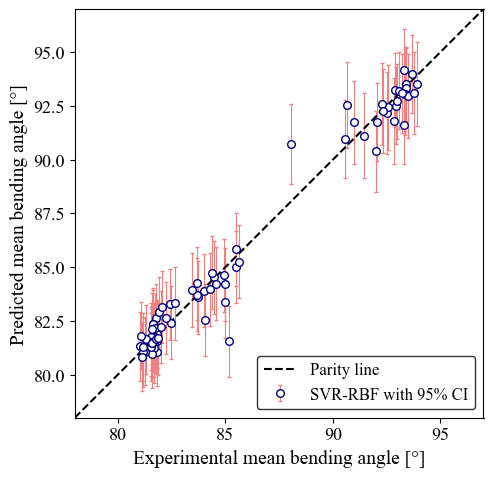


Block 9 execution completed. Uncertainty metrics and parity plots generated successfully.


In [18]:
# ==============================================================================
# BLOCK 9: QUANTITATIVE UNCERTAINTY QUANTIFICATION & JOURNAL ERROR BAR PLOT
# ==============================================================================
# This block implements a rigorous metrological uncertainty propagation framework
# in compliance with ISO-GUM guidelines. It propagates input tolerances through 
# SVR-RBF gradients and computes the total expanded prediction uncertainty budget.

# Define standard uncertainties (u) for physical process measurements/tolerances
u_A_val = 1.25   # %t (standard uncertainty of grooving depth)
u_B_val = 0.15   # Degree (standard uncertainty of grooving angle)
u_C_val = 0.01   # mm (standard uncertainty of tool nose radius)
u_D_val = 0.0    # Rolling direction is treated as categorical/exact (zero variance)

# Define intrinsic model uncertainty using the prediction RMSE from fair LOO-CV
u_model_intrinsic = svr_metrics["RMSE"] 

def evaluate_svr_local_gradient_numerical(model, X_point, epsilon_h=1e-5):
    """
    Approximates local sensitivity coefficients (partial derivatives: df/dx_i) 
    for the non-linear SVR-RBF model at a specific design point using 
    the central difference numerical approximation method.
    """
    grad = np.zeros(len(model_features))
    X_base = X_point.copy()
    for idx, feature in enumerate(model_features):
        X_plus = X_base.copy()
        X_minus = X_base.copy()
        
        # Perturb feature in positive and negative directions
        X_plus[feature] += epsilon_h
        X_minus[feature] -= epsilon_h
        
        y_plus = model.predict(X_plus)[0]
        y_minus = model.predict(X_minus)[0]
        
        # Central difference formula: df/dx = (f(x + h) - f(x - h)) / (2 * h)
        grad[idx] = (y_plus - y_minus) / (2 * epsilon_h)
    return grad

def calculate_propagated_uncertainty_gum(model, X_df):
    """
    Propagates input uncertainties through the SVR-RBF model using 
    the GUM Law of Propagation of Uncertainty (first-order Taylor expansion).
    Total Variance = Sum of (Sensitivity_i * u_input_i)^2 + Intrinsic_Model_Variance
    """
    combined_standard_u = []
    expanded_u = []
    prop_meas_ratio = []
    u_inputs = np.array([u_A_val, u_B_val, u_C_val, u_D_val])
    
    for i in range(len(X_df)):
        X_point = X_df.iloc[[i]].copy()
        
        # Step 1: Compute local sensitivity coefficients (df/dx_i)
        sensitivity = evaluate_svr_local_gradient_numerical(model, X_point)
        
        # Step 2: Propagate input measurement variance
        var_propagated = np.sum((sensitivity * u_inputs) ** 2)
        
        # Step 3: Combine with SVR model intrinsic variance: u_total^2 = var_prop + u_model^2
        var_total = var_propagated + (u_model_intrinsic ** 2)
        u_combined = np.sqrt(var_total)
        
        # Step 4: Compute Expanded Uncertainty (U) with coverage factor k=2 (~95% CI)
        U_expanded = 2 * u_combined 
        
        # Step 5: Quantify error budget contribution ratio (%)
        ratio = (var_propagated / var_total) * 100.0
        
        combined_standard_u.append(u_combined)
        expanded_u.append(U_expanded)
        prop_meas_ratio.append(ratio)
        
    return np.array(combined_standard_u), np.array(expanded_u), np.array(prop_meas_ratio)

# Calculate uncertainty propagation for the representative case studies
combined_u_cases, expanded_u_cases, meas_ratio_cases = calculate_propagated_uncertainty_gum(final_model, X_case)

# Create uncertainty analysis DataFrame with expanded confidence intervals (95% CI)
uncertainty_case_analysis_df = pd.DataFrame({
    "Case": [1, 2, 3],
    "A [%t]": X_case["A [%t]"],
    "B [°]": X_case["B [°]"],
    "C [mm]": X_case["C [mm]"],
    "SVR-RBF Pred [°]": svr_case_predictions,
    "95% CI Limit [°]": [f"± {val:.4f}" for val in expanded_u_cases],
    "SVR-RBF 95% CI [°]": [f"{p:.2f} ± {u:.2f}" for p, u in zip(svr_case_predictions, expanded_u_cases)],
    "Meas. Error Contrib. (%)": meas_ratio_cases,
    "Model Error Contrib. (%)": 100.0 - meas_ratio_cases
})

print("\n" + "=" * 72)
print("BLOCK 9: QUANTIFIED UNCERTAINTY FOR REPRESENTATIVE CASES")
print("=" * 72)
print(uncertainty_case_analysis_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Export quantified uncertainty budget to a separate Excel file
uncertainty_case_analysis_df.to_excel(
    os.path.join(output_dir, "representative_case_study_uncertainty_analysis.xlsx"), 
    index=False
)

# Propagate uncertainty across the entire experimental dataset (81 samples)
dataset_combined_u, dataset_expanded_u, dataset_meas_ratio = calculate_propagated_uncertainty_gum(final_model, X)
avg_meas_contrib = np.mean(dataset_meas_ratio)
avg_model_contrib = 100.0 - avg_meas_contrib

print("\nGLOBAL METROLOGICAL BUDGET SUMMARY:")
print(f"Average Propagated Measurement Error Contribution: {avg_meas_contrib:.2f}%")
print(f"Average Intrinsic ML Model Discrepancy Contribution: {avg_model_contrib:.2f}%")

# Generate journal-style SVR-RBF parity plot featuring GUM expanded uncertainty bars
plt.figure(figsize=(5.5, 5.0))
plt.errorbar(
    y_true_vals, 
    y_pred_rbf, 
    yerr=dataset_expanded_u, 
    fmt="o", 
    markersize=5.5, 
    color="navy",
    markerfacecolor="white", 
    markeredgecolor="navy", 
    markeredgewidth=1.0, 
    ecolor="lightcoral", 
    elinewidth=0.8, 
    capsize=1.5, 
    label="SVR-RBF with 95% CI"
)

plt.plot([78, 97], [78, 97], linestyle="--", linewidth=1.5, color="black", label="Parity line")
plt.xlim(78, 97)
plt.ylim(78, 97)
plt.xlabel("Experimental mean bending angle [°]", fontsize=14)
plt.ylabel("Predicted mean bending angle [°]", fontsize=14)
plt.gca().set_aspect("equal", adjustable="box")

leg = plt.legend(loc="lower right", frameon=True, edgecolor="black")
leg.get_frame().set_linewidth(1.0)

ax = plt.gca()
ax.tick_params(axis="both", colors="black", labelsize=13)
for spine in ax.spines.values():
    spine.set_color("black")

plt.tight_layout()
save_publication_figure("fit_plot_rbf_with_uncertainty_error_bars")
plt.show()
print("\nBlock 9 execution completed. Uncertainty metrics and parity plots generated successfully.")